# Introduction to Pandas

**pandas** is a Python package providing fast, flexible, and expressive data structures designed to work with *relational* or *labeled* data both. It is a fundamental high-level building block for doing practical, real world data analysis in Python.

pandas is well suited for:

- Tabular data with heterogeneously-typed columns, as in an SQL table or Excel spreadsheet
- Ordered and unordered (not necessarily fixed-frequency) time series data.
- Arbitrary matrix data (homogeneously typed or heterogeneous) with row and column labels
- Any other form of observational / statistical data sets. The data actually need not be labeled at all to be placed into a pandas data structure


Key features:
    
- Easy handling of **missing data**
- **Size mutability**: columns can be inserted and deleted from DataFrame and higher dimensional objects
- Automatic and explicit **data alignment**: objects can be explicitly aligned to a set of labels, or the data can be aligned automatically
- Powerful, flexible **group by functionality** to perform split-apply-combine operations on data sets
- Intelligent label-based **slicing, fancy indexing, and subsetting** of large data sets
- Intuitive **merging and joining** data sets
- Flexible **reshaping and pivoting** of data sets
- **Hierarchical labeling** of axes
- Robust **IO tools** for loading data from flat files, Excel files, databases, and HDF5
- **Time series functionality**: date range generation and frequency conversion, moving window statistics, moving window linear regressions, date shifting and lagging, etc.

Note:
> * While pandas adopts many coding idioms from NumPy, the biggest difference is that pandas is designed for working with tabular or heterogeneous data.

> * NumPy, by contrast, is best suited for working with homogeneous numerical array data.



Matplotlib inline is a backend command in Jupyter Notebooks that enables the rendering of Matplotlib plots directly below code cells.

This means that when we execute code that generates Matplotlib plots, the plots are displayed inline within the notebook, rather than in a separate window or output cell.

In [1]:
# Importing numpy for intermittent uses
import numpy as np

In [2]:
# Most of the developers use the following import convention for pandas:
import pandas as pd

# Whenever we see "pd." in code, it’s referring to pandas.
# We may also find it easier to import Series and DataFrame into the local namespace since they are so frequently used:
from pandas import Series, DataFrame

## **Introduction to pandas Data Structures**

To get started with pandas, we will need to get comfortable with its two workhorse data structures: **Series** and **DataFrame**.

While they are not a universal solution for every problem, they provide a solid, easy-to-use basis for most applications.

### **Series**

A Series is a one-dimensional array-like object **containing a sequence of values** (of similar types to NumPy types) and **an associated array of data labels, called its index**.

The simplest Series is formed from only an array of data:

In [3]:
obj = pd.Series([4, 7, -5, 3])
obj

,0
0,4
1,7
2,-5
3,3


a Series displayed interactively shows the index on the left and the values on the right.

Since we did not specify an index for the data, a default one consisting of the integers 0 through N - 1 (where N is the length of the data) is created.

we can get the array representation and index object of the Series via its values and index attributes, respectively:

Often it will be desirable to create a Series with an index identifying each data point with a label:

In [4]:
obj2 = pd.Series([4, 7, -5, 3], index=['d', 'b', 'a', 'c'])
obj

,0
0,4
1,7
2,-5
3,3


In [5]:
obj2.index

Index(['d', 'b', 'a', 'c'], dtype='object')

Compared with NumPy arrays, we can use labels in the index when selecting single values or a set of values:

In [6]:
print(obj2['a'])
print(obj2['d'])

-5
4


Here ['c', 'a', 'd'] is interpreted as a list of indices, even though it contains strings instead of integers.

In [7]:
obj2[['c','a','d']]

,0
c,3
a,-5
d,4


Using NumPy functions or NumPy-like operations, such as filtering with a boolean
array, scalar multiplication, or applying math functions, will preserve the index-value
link:

In [ ]:
obj2[obj2 > 0]

,0
d,4
b,7
c,3


In [ ]:
obj2 * 2

,0
d,8
b,14
a,-10
c,6


In [ ]:
np.exp(obj2)

,0
d,54.598150
b,1096.633158
a,0.006738
c,20.085537


Another way to think about a Series is as a fixed-length, ordered dict, as it is a mapping of index values to data values.

It can be used in many contexts where we might use a dict:

In [ ]:
'b' in obj2

True

In [ ]:
'e' in obj2

False

Should we have data contained in a Python dict, we can create a Series from it by passing the dict:

In [8]:
sdata = {'Ohio': 35000, 'Texas': 71000, 'Oregon': 16000, 'Utah': 5000}
obj3 = pd.Series(sdata)
obj3

,0
Ohio,35000
Texas,71000
Oregon,16000
Utah,5000


we can override the order by passing the dict keys in the order we
want them to appear in the resulting Series:

In [ ]:
states = ['California', 'Ohio', 'Oregon', 'Texas']
obj4 = pd.Series(sdata, states)
obj4

,0
California,NaN
Ohio,35000.0
Oregon,16000.0
Texas,71000.0


Here, three values found in `sdata` were placed in the appropriate locations, but since no value for `'California'` was found, it appears as `NaN` (not a number), which is considered in pandas to mark missing or `NaN` values.

Since `'Utah'` was not included in states, it is excluded from the resulting object.

We use the terms “missing” or “NA” interchangeably to refer to missing data.

The `isnull` and `notnull` functions in pandas should be used to detect missing data:

In [ ]:
pd.isnull(obj4)

,0
California,True
Ohio,False
Oregon,False
Texas,False


In [ ]:
pd.notnull(obj4)

,0
California,False
Ohio,True
Oregon,True
Texas,True


In [ ]:
# Series also has these as instance methods:
obj4.isnull()

,0
California,True
Ohio,False
Oregon,False
Texas,False


A useful Series feature for many applications is that it automatically aligns by index label in arithmetic operations:

In [ ]:
obj3

,0
Ohio,35000
Texas,71000
Oregon,16000
Utah,5000


In [ ]:
obj4

,0
California,NaN
Ohio,35000.0
Oregon,16000.0
Texas,71000.0


In [ ]:
obj3 + obj4

,0
California,NaN
Ohio,70000.0
Oregon,32000.0
Texas,142000.0
Utah,NaN


we can think about this as being similar to a join operation

Both the Series object itself and its index have a name attribute, which integrates with other key areas of pandas functionality:

In [ ]:
obj4.name = 'population'
obj4.index.name = 'state'
obj4

,population
state,
California,NaN
Ohio,35000.0
Oregon,16000.0
Texas,71000.0


A Series’s index can be altered in-place by assignment:

In [ ]:
obj

,0
0,4
1,7
2,-5
3,3


In [10]:
obj.index = ['Bob', 'Steve', 'Jeff', 'Ryan']
obj

,0
Bob,4
Steve,7
Jeff,-5
Ryan,3


### **DataFrame**

A DataFrame represents a rectangular table of data and contains an ordered collection of columns, each of which can be a different value type (numeric, string, boolean, etc.).

The DataFrame has both a row and column index; it can be thought of as a dict of Series all sharing the same index.

Under the hood, the data is stored as one or more two-dimensional blocks rather than a list, dict, or some other collection of one-dimensional arrays.

There are many ways to construct a DataFrame, though one of the most common is
from a dict of equal-length lists or NumPy arrays:

In [11]:
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
        'year': [2000, 2001, 2002, 2001, 2002, 2003],
        'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}

frame = pd.DataFrame(data)

frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


While using the Jupyter/Colab notebook, pandas DataFrame objects are displayed as a more browser-friendly HTML table

For large DataFrames, the head method selects only the first five rows:

In [12]:
frame.head()

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9


If we specify a sequence of columns, the DataFrame’s columns will be arranged in that order:

In [ ]:
pd.DataFrame(data, columns=['year', 'state', 'pop'])

,year,state,pop
0,2000,Ohio,1.5
1,2001,Ohio,1.7
2,2002,Ohio,3.6
3,2001,Nevada,2.4
4,2002,Nevada,2.9
5,2003,Nevada,3.2


If we pass a column that isn't contained in the dict, it will appear with missing values in the result:

In [25]:
frame2 = pd.DataFrame(data,
                      columns=['year', 'state', 'pop', 'debt'],
                      index=['one', 'two', 'three', 'four','five', 'six'])

frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


A column in a DataFrame can be retrieved as a Series either by dict-like notation or by attribute:

In [19]:
frame2.columns

Index(['year', 'state', 'pop', '3ebt'], dtype='object')

In [21]:
frame2['state']


,3ebt
one,NaN
two,NaN
three,NaN
four,NaN
five,NaN
six,NaN


In [23]:
frame2.year
# frame2.state


,year
one,2000
two,2001
three,2002
four,2001
five,2002
six,2003


`frame2[column]` works for any column name, but `frame2.column` only works when the column name is a valid Python variable name.

Columns can be modified by assignment. For example, the empty 'debt' column
could be assigned a scalar value or an array of values:

In [30]:
# frame2['debt'] = 16.5
# frame2['debt'] = [16.5, 10.2, 44.5, 98.2, 65.1, 10.2]
frame2['debt'] = np.arange(6.)

frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0.0
two,2001,Ohio,1.7,1.0
three,2002,Ohio,3.6,2.0
four,2001,Nevada,2.4,3.0
five,2002,Nevada,2.9,4.0
six,2003,Nevada,3.2,5.0


When we are assigning lists or arrays to a column, the value’s length must match the length of the DataFrame.

If we assign a Series, its labels will be realigned exactly to the DataFrame’s index, inserting missing values in any holes:

In [32]:
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
# val
frame2['debt'] = val
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


Assigning a column that doesn’t exist will create a new column.

The del keyword will delete columns as with a dict.

In [33]:
frame2['eastern'] = frame2.state == 'Ohio'
frame2

,year,state,pop,debt,eastern
one,2000,Ohio,1.5,NaN,True
two,2001,Ohio,1.7,-1.2,True
three,2002,Ohio,3.6,NaN,True
four,2001,Nevada,2.4,-1.5,False
five,2002,Nevada,2.9,-1.7,False
six,2003,Nevada,3.2,NaN,False


In [34]:
del frame2['eastern']
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


Another common form of data is a nested dict of dicts.

If the nested dict is passed to the DataFrame, pandas will interpret the outer dict keys as the columns and the inner keys as the row indices:

In [36]:
pop = {'Nevada': {2001: 2.4, 2002: 2.9},
       'Ohio': {2000: 1.5, 2001: 1.7, 2002: 3.6}}

frame3 = pd.DataFrame(pop)
frame3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


we can transpose the DataFrame (swap rows and columns) with similar syntax to a
NumPy array:

In [37]:
frame3.T

,2001,2002,2000
Nevada,2.4,2.9,NaN
Ohio,1.7,3.6,1.5


The keys in the inner dicts are combined and sorted to form the index in the result.

This isn’t true if an explicit index is specified:

In [39]:
pd.DataFrame(pop, index=[2000, 2001, 2003, 2002])

,Nevada,Ohio
2000,NaN,1.5
2001,2.4,1.7
2003,NaN,NaN
2002,2.9,3.6


Dicts of Series are treated in much the same way:

In [40]:
frame3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [42]:
pdata = {'Ohio': frame3['Ohio'][:-1],
         'Nevada': frame3['Nevada'][:2]}

pd.DataFrame(pdata)

,Ohio,Nevada
2001,1.7,2.4
2002,3.6,2.9


Refer to the following table to get a complete list of things we can pass the DataFrame constructor



If a DataFrame’s index and columns have their name attributes set, these will also be displayed:

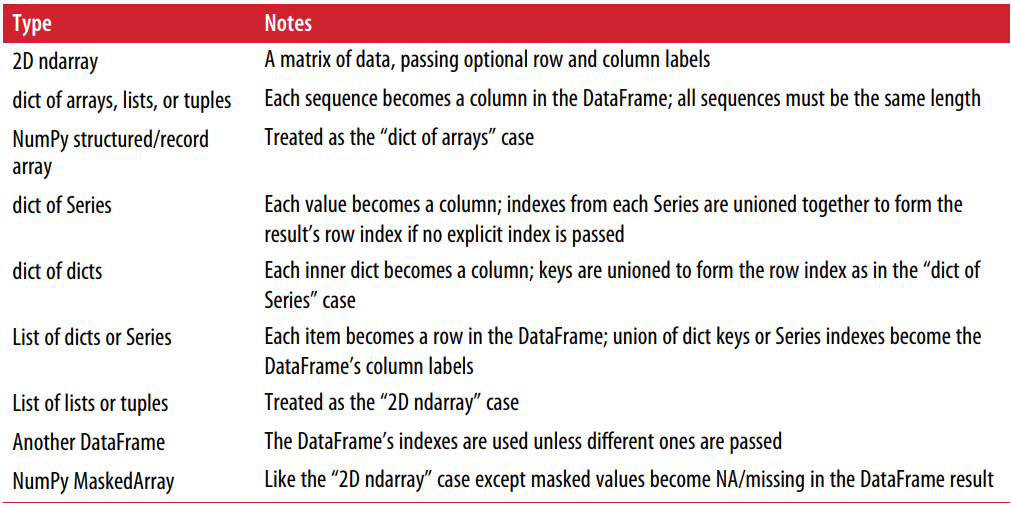

In [43]:
frame3.index.name = 'year'; frame3.columns.name = 'state'
frame3

state,Nevada,Ohio
year,,
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


As with Series, the values attribute returns the data contained in the DataFrame as a two-dimensional ndarray:

In [44]:
frame3.values

array([[2.4, 1.7],
       [2.9, 3.6],
       [nan, 1.5]])

If the DataFrame’s columns are different dtypes, the dtype of the values array will be
chosen to accommodate all of the columns:

In [45]:
frame2.values

array([[2000, 'Ohio', 1.5, nan],
       [2001, 'Ohio', 1.7, -1.2],
       [2002, 'Ohio', 3.6, nan],
       [2001, 'Nevada', 2.4, -1.5],
       [2002, 'Nevada', 2.9, -1.7],
       [2003, 'Nevada', 3.2, nan]], dtype=object)

## **Essential Functionality**

This will walk you through the fundamental mechanics of interacting with the data contained in a Series or DataFrame

### **Index Objects**

pandas's Index objects are responsible for holding the axis labels and other metadata (like the axis name or names).

Any array or other sequence of labels we use when constructing a Series or DataFrame is internally converted to an Index:

In [46]:
obj = pd.Series(range(3), index=['a', 'b', 'c'])
index = obj.index

index

Index(['a', 'b', 'c'], dtype='object')

In [47]:
index[1:]

Index(['b', 'c'], dtype='object')

Index objects are immutable and thus can’t be modified by the user.

### **Reindexing**

An important method on pandas objects is reindex, which means to create a new object with the data conformed to a new index.

In [48]:
obj = pd.Series([4.5, 7.2, -5.3, 3.6], index=['d', 'b', 'a', 'c'])
obj

,0
d,4.5
b,7.2
a,-5.3
c,3.6


Calling reindex on this Series rearranges the data according to the new index, introducing missing values if any index values were not already present:

In [ ]:
obj2 = obj.reindex(['a', 'b', 'c', 'd', 'e'])
obj2

,0
a,-5.3
b,7.2
c,3.6
d,4.5
e,NaN


### **Dropping Entries from an Axis**

Dropping one or more entries from an axis is easy if we already have an index array or list without those entries.

As that can require a bit of munging and set logic, the drop method will return a new object with the indicated value or values deleted from an axis.

In [49]:
obj = pd.Series(np.arange(5.), index = ['a', 'b', 'c', 'd', 'e'])
obj

,0
a,0.0
b,1.0
c,2.0
d,3.0
e,4.0


In [50]:
new_obj = obj.drop('c')

new_obj

,0
a,0.0
b,1.0
d,3.0
e,4.0


With DataFrame, index values can be deleted from either axis.

In [51]:
# we first create an example DataFrame:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])

data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


Calling drop with a sequence of labels will drop values from the row labels (axis 0):

In [52]:
data.drop(['Colorado', 'Ohio'])

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


we can drop values from the columns by passing axis=1 or axis='columns':

In [ ]:
data.drop('two', axis=1)

,one,three,four
Ohio,0,2,3
Colorado,4,6,7
Utah,8,10,11
New York,12,14,15


In [ ]:
data.drop(['two', 'four'], axis='columns')

,one,three
Ohio,0,2
Colorado,4,6
Utah,8,10
New York,12,14


### **Indexing, Selection, and Filtering**

Series indexing (obj[...]) works analogously to NumPy array indexing, except we can use the Series’s index values instead of only integers.

In [56]:
obj = pd.Series(np.arange(4.), index=['a', 'b', 'c', 'd'])
obj

,0
a,0.0
b,1.0
c,2.0
d,3.0


In [57]:
obj['b']

1.0

In [61]:
obj[2:4]

,0
c,2.0
d,3.0


Slicing with labels behaves differently than normal Python slicing in that the endpoint is inclusive:

In [64]:
obj['c':'d']

,0
c,2.0
d,3.0


Setting using these methods modifies the corresponding section of the Series:

In [65]:
obj['b':'c'] = 5
obj

,0
a,0.0
b,5.0
c,5.0
d,3.0


Indexing into a DataFrame is for retrieving one or more columns either with a single value or sequence:

In [66]:
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['Ohio', 'Colorado', 'Utah', 'New York'],
                    columns=['one', 'two', 'three', 'four'])

data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [ ]:
data['two']

,two
Ohio,1
Colorado,5
Utah,9
New York,13


In [ ]:
data[['three', 'one']]

,three,one
Ohio,2,0
Colorado,6,4
Utah,10,8
New York,14,12


Indexing like this has a few special cases. First, slicing or selecting data with a boolean
array:

In [ ]:
data[:2]

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7


In [ ]:
data[data['three'] > 5]

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


### **Selection with loc and iloc**

For DataFrame label-indexing on the rows, we can use the special indexing operators loc and iloc.

They enable you to select a subset of the rows and columns from a DataFrame with NumPy-like notation using either axis labels (loc) or integers (iloc)

In [ ]:
data.loc['Colorado', ['two', 'three']]

,Colorado
two,5
three,6


In [ ]:
data.iloc[2, [3, 0, 1]]

,Utah
four,11
one,8
two,9


In [ ]:
data.iloc[2]

,Utah
one,8
two,9
three,10
four,11


In [ ]:
data.iloc[[1, 2], [3, 0, 1]]

,four,one,two
Colorado,7,4,5
Utah,11,8,9


Both indexing functions work with slices in addition to single labels or lists of labels:

In [ ]:
data.loc[:'Utah', 'two']

,two
Ohio,1
Colorado,5
Utah,9


In [ ]:
data.iloc[:, :3][data.three > 5]

,one,two,three
Colorado,4,5,6
Utah,8,9,10
New York,12,13,14


There are many ways to select and rearrange the data contained in a pandas object.

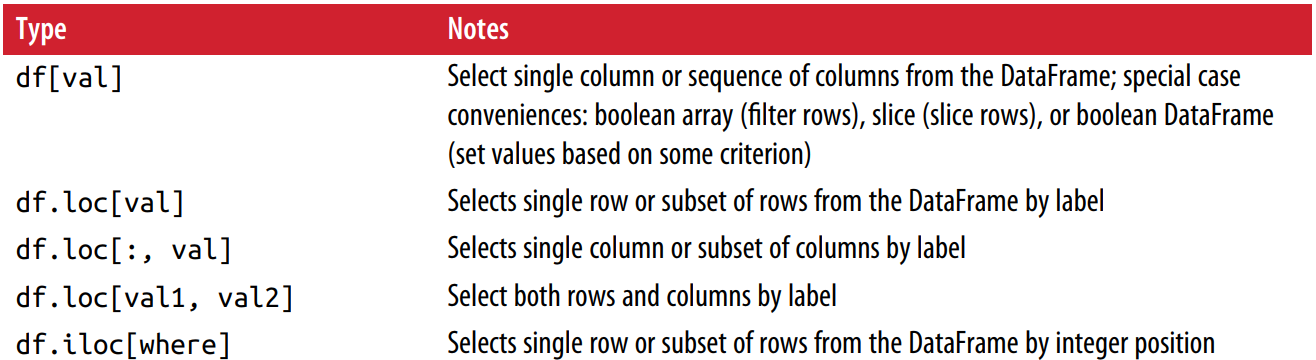
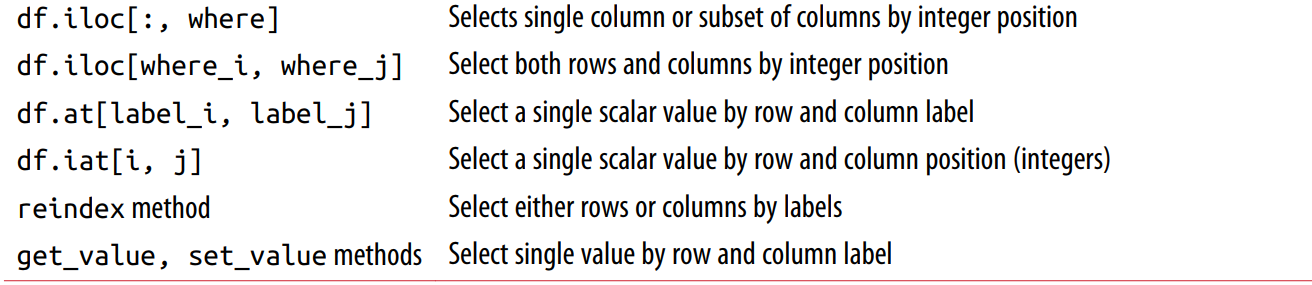

### **Arithmetic and Data Alignment**

When you are adding together objects, if any index pairs are not the same, the respective index in the result will be the union of the index pairs.

This is similar to an automatic outer join on the index labels.

In [68]:
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=['a', 'c', 'd', 'e'])
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=['a', 'c', 'e', 'f', 'g'])

s1

,0
a,7.3
c,-2.5
d,3.4
e,1.5


In [69]:
s2

,0
a,-2.1
c,3.6
e,-1.5
f,4.0
g,3.1


In [ ]:
s1 + s2

,0
a,5.2
c,1.1
d,NaN
e,0.0
f,NaN
g,NaN


The internal data alignment introduces missing values in the label locations that don’t overlap.

Missing values will then propagate in further arithmetic computations.

In the case of DataFrame, alignment is performed on both the rows and the columns:

In [70]:
df1 = pd.DataFrame(np.arange(9.).reshape((3, 3)), columns=list('bcd'),
                  index=['Ohio', 'Texas', 'Colorado'])
df2 = pd.DataFrame(np.arange(12.).reshape((4, 3)), columns=list('bde'),
                   index=['Utah', 'Ohio', 'Texas', 'Oregon'])

In [71]:
df1

,b,c,d
Ohio,0.0,1.0,2.0
Texas,3.0,4.0,5.0
Colorado,6.0,7.0,8.0


In [72]:
df2

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


Adding these together returns a DataFrame whose index and columns are the unions of the ones in each DataFrame:

In [73]:
df1 + df2

,b,c,d,e
Colorado,NaN,NaN,NaN,NaN
Ohio,3.0,NaN,6.0,NaN
Oregon,NaN,NaN,NaN,NaN
Texas,9.0,NaN,12.0,NaN
Utah,NaN,NaN,NaN,NaN


Since the 'c' and 'e' columns are not found in both DataFrame objects, they appear as all missing in the result.

The same holds for the rows whose labels are not common to both objects. For uncommon rows, we can imagine as if the existing data is being added to a NaN so the result is NaN.

If we add DataFrame objects with no column or row labels in common, the result
will contain all nulls:

In [74]:
df1 = pd.DataFrame({'A': [1, 2]})
df2 = pd.DataFrame({'B': [3, 4]})
print(df1)
print(df2)
print(df1+df2)

   A
0  1
1  2
   B
0  3
1  4
    A   B
0 NaN NaN
1 NaN NaN


### **Arithmetic methods with fill values**

In arithmetic operations between differently indexed objects, you might want to fill with a special value, like 0, when an axis label is found in one object but not the other:

In [76]:
# list('abcd')

['a', 'b', 'c', 'd']

In [75]:
df1 = pd.DataFrame(np.arange(12.).reshape((3, 4)),
                   columns=list('abcd'))
df2 = pd.DataFrame(np.arange(20.).reshape((4, 5)),
                   columns=list('abcde'))
df2.loc[1, 'b'] = np.nan


In [77]:
df1

,a,b,c,d
0,0.0,1.0,2.0,3.0
1,4.0,5.0,6.0,7.0
2,8.0,9.0,10.0,11.0


In [78]:
df2

,a,b,c,d,e
0,0.0,1.0,2.0,3.0,4.0
1,5.0,NaN,7.0,8.0,9.0
2,10.0,11.0,12.0,13.0,14.0
3,15.0,16.0,17.0,18.0,19.0


Adding these together results in NA values in the locations that don’t overlap:

In [ ]:
df1 + df2

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,NaN
1,9.0,NaN,13.0,15.0,NaN
2,18.0,20.0,22.0,24.0,NaN
3,NaN,NaN,NaN,NaN,NaN


Using the add method on df1, pass df2 and an argument to fill_value:

In [ ]:
df1.add(df2, fill_value=0)

,a,b,c,d,e
0,0.0,2.0,4.0,6.0,4.0
1,9.0,5.0,13.0,15.0,9.0
2,18.0,20.0,22.0,24.0,14.0
3,15.0,16.0,17.0,18.0,19.0


When reindexing a Series or DataFrame, you can also specify a different fill
value:

In [80]:
df1.reindex(columns=df2.columns, fill_value=1)

,a,b,c,d,e
0,0.0,1.0,2.0,3.0,1
1,4.0,5.0,6.0,7.0,1
2,8.0,9.0,10.0,11.0,1


these two statements are equivalent:
```
1 / df1
df1.rdiv(1)
```


In [ ]:
1 / df1

,a,b,c,d
0,inf,1.000000,0.500000,0.333333
1,0.250,0.200000,0.166667,0.142857
2,0.125,0.111111,0.100000,0.090909


In [ ]:
df1.rdiv(1)

,a,b,c,d
0,inf,1.000000,0.500000,0.333333
1,0.250,0.200000,0.166667,0.142857
2,0.125,0.111111,0.100000,0.090909


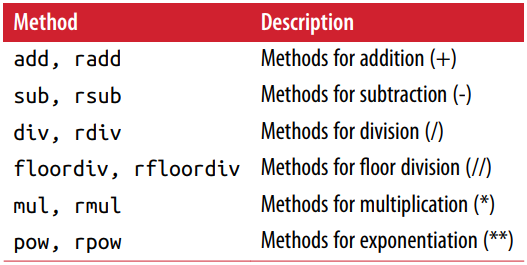

### **Operations between DataFrame and Series**

As with NumPy arrays of different dimensions, arithmetic between DataFrame and Series is also defined.

First, as a motivating example, consider the difference between a two-dimensional array and one of its rows:

Consider the difference between a two-dimensional array and one of its rows:

In [ ]:
arr = np.arange(12.).reshape((3, 4))
arr

array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.]])

In [ ]:
arr[0]

array([0., 1., 2., 3.])

In [ ]:
arr - arr[0]

array([[0., 0., 0., 0.],
       [4., 4., 4., 4.],
       [8., 8., 8., 8.]])

When we subtract arr[0] from arr, the subtraction is performed once for each row.

This is referred to as broadcasting

Operations between a DataFrame and a Series are similar:

In [82]:
frame = pd.DataFrame(np.arange(12.).reshape((4, 3)),
                     columns=list('bde'),
                     index=['Utah', 'Ohio', 'Texas', 'Oregon'])

In [83]:
series = frame.iloc[0]

In [84]:
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [85]:
series

,Utah
b,0.0
d,1.0
e,2.0


By default, arithmetic between DataFrame and Series matches the index of the Series on the DataFrame’s columns, broadcasting down the rows:

In [86]:
frame - series

,b,d,e
Utah,0.0,0.0,0.0
Ohio,3.0,3.0,3.0
Texas,6.0,6.0,6.0
Oregon,9.0,9.0,9.0


If an index value is not found in either the DataFrame’s columns or the Series’s index,
the objects will be reindexed to form the union:

In [87]:
series2 = pd.Series(range(3), index=['b', 'e', 'f'])
series2

,0
b,0
e,1
f,2


In [88]:
frame + series2

,b,d,e,f
Utah,0.0,NaN,3.0,NaN
Ohio,3.0,NaN,6.0,NaN
Texas,6.0,NaN,9.0,NaN
Oregon,9.0,NaN,12.0,NaN


If you want to instead broadcast over the columns, matching on the rows, you have to
use one of the arithmetic methods.

In [89]:
series3 = frame['d']
frame

,b,d,e
Utah,0.0,1.0,2.0
Ohio,3.0,4.0,5.0
Texas,6.0,7.0,8.0
Oregon,9.0,10.0,11.0


In [ ]:
series3

,d
Utah,1.0
Ohio,4.0
Texas,7.0
Oregon,10.0


Here we subtract Column 'd' from all columns. We are matching the respective rows.

In [ ]:
frame.sub(series3, axis='index')

,b,d,e
Utah,-1.0,0.0,1.0
Ohio,-1.0,0.0,1.0
Texas,-1.0,0.0,1.0
Oregon,-1.0,0.0,1.0


The axis number that you pass is the axis to match on. In this case we mean to match
on the DataFrame’s row index (axis='index' or axis=0) and broadcast across.

### **Function Application and Mapping**

NumPy `ufuncs` (element-wise array methods) also work with pandas objects:


In [92]:
frame = pd.DataFrame(np.random.randn(4, 3), columns=list('bde'),
                     index=['Utah', 'Ohio', 'Texas', 'Oregon'])
frame

,b,d,e
Utah,0.620876,-0.238524,-1.509140
Ohio,-0.642006,1.608513,-0.610864
Texas,-1.497130,-1.395245,0.499767
Oregon,-1.337020,1.354291,0.229557


In [91]:
np.abs(frame)

,b,d,e
Utah,0.836390,0.471204,0.910623
Ohio,1.279075,0.917701,0.709697
Texas,0.563077,0.508374,0.836092
Oregon,0.073425,0.354754,1.053315


Another frequent operation is applying a function on one-dimensional arrays to each
column or row.

DataFrame’s apply method does exactly this

In [93]:
f = lambda x: x.max() - x.min()
frame.apply(f)

,0
b,2.118006
d,3.003758
e,2.008907


Here the function f, which computes the difference between the maximum and minimum of a Series, is invoked once on each column in frame.

The result is a Series having the columns of frame as its index.

If you pass axis='columns' to apply, the function will be invoked once per row instead:

In [94]:
frame.apply(f, axis='columns')

,0
Utah,2.130016
Ohio,2.250518
Texas,1.996897
Oregon,2.691311


Many of the most common array statistics (like sum and mean) are DataFrame methods, so using apply is not necessary.


The function passed to apply need not return a scalar value; it can also return a Series with multiple values:

In [ ]:
def f(x):
  return pd.Series([x.min(), x.max()], index=['min', 'max'])

In [ ]:
frame.apply(f)

,b,d,e
min,-0.786371,-1.198846,-1.608542
max,-0.202946,1.159036,1.119854


Element-wise Python functions can be used, too.

Suppose we wanted to compute a formatted string from each floating-point value in frame.

We can do this with apply map. Series has a map method for applying an
element-wise function

In [ ]:
format = lambda x: '%.2f' %x

frame.map(format)

,b,d,e
Utah,-0.68,-1.20,-0.15
Ohio,-0.48,0.95,-1.61
Texas,-0.20,1.16,0.72
Oregon,-0.79,0.48,1.12


In [ ]:
frame['e'].map(format)

,e
Utah,-0.15
Ohio,-1.61
Texas,0.72
Oregon,1.12


### **Sorting**

Sorting a dataset by some criterion is another important built-in operation.

To sort lexicographically by row or column index, use the sort_index method, which returns a new, sorted object

In [ ]:
obj = pd.Series(range(4), index=['d', 'a', 'b', 'c'])

obj.sort_index()

,0
a,1
b,2
c,3
d,0


With a DataFrame, you can sort by index on either axis:

In [ ]:
frame = pd.DataFrame(np.arange(8).reshape((2, 4)),
                     index=['three', 'one'],
                     columns=['d', 'a', 'b', 'c'])

frame.sort_index()

,d,a,b,c
one,4,5,6,7
three,0,1,2,3


In [ ]:
frame.sort_index(axis=1)

,a,b,c,d
three,1,2,3,0
one,5,6,7,4


The data is sorted in ascending order by default, but can be sorted in descending order, too:

In [ ]:
frame.sort_index(axis=1, ascending=False)

,d,c,b,a
three,0,3,2,1
one,4,7,6,5


To sort a Series by its values, use its sort_values method:

In [ ]:
obj = pd.Series([4, 7, -3, 2])


obj.sort_values()

,0
2,-3
3,2
0,4
1,7


Any missing values are sorted to the end of the Series by default:


In [ ]:
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])

obj.sort_values()

,0
4,-3.0
5,2.0
0,4.0
2,7.0
1,NaN
3,NaN


When sorting a DataFrame, you can use the data in one or more columns as the sort keys.

To do so, pass one or more column names to the by option of sort_values:

In [ ]:
frame = pd.DataFrame({'b': [4, 7, -3, 2], 'a': [0, 1, 0, 1]})


frame

,b,a
0,4,0
1,7,1
2,-3,0
3,2,1


In [ ]:
frame.sort_values(by='b')

,b,a
2,-3,0
3,2,1
0,4,0
1,7,1


To sort by multiple columns, pass a list of names:

In [ ]:
frame.sort_values(by=['a', 'b'])

,b,a
2,-3,0
0,4,0
3,2,1
1,7,1


Ranking assigns ranks from one through the number of valid data points in an array.

By default rank breaks ties by assigning each group the mean rank:

In [ ]:
obj = pd.Series([7, -5, 7, 4, 2, 0, 4])

obj.rank()

,0
0,6.5
1,1.0
2,6.5
3,4.5
4,3.0
5,2.0
6,4.5


### **Axis Indexes with Duplicate Labels**

Up until now all of the examples we’ve looked at have had unique axis labels (index values).
While many pandas functions (like reindex) require that the labels be unique, it’s not mandatory.

Let’s consider a small Series with duplicate indices:

In [95]:
obj = pd.Series(range(5), index=['a', 'a', 'b', 'b', 'c'])
obj

,0
a,0
a,1
b,2
b,3
c,4


The index’s is_unique property can tell you whether its labels are unique or not:

In [96]:
obj.index.is_unique

False

Data selection is one of the main things that behaves differently with duplicates.

Indexing a label with multiple entries returns a Series, while single entries return a scalar value:

In [ ]:
obj['a']

,0
a,0
a,1


In [ ]:
obj['c']

4

This can make your code more complicated, as the output type from indexing can
vary based on whether a label is repeated or not.


The same logic extends to indexing rows in a DataFrame:


In [ ]:
df = pd.DataFrame(np.random.randn(4, 3), index=['a', 'a', 'b', 'b'])
df

,0,1,2
a,0.763830,-1.450074,0.378229
a,-0.321624,1.570434,-1.155547
b,1.470869,1.211534,0.330043
b,-1.662825,0.509650,-0.514527


In [ ]:
df.loc['b']

,0,1,2
b,1.470869,1.211534,0.330043
b,-1.662825,0.509650,-0.514527


## **Summarizing and Computing Descriptive Statistics**

pandas objects are equipped with a set of common mathematical and statistical methods.

Most of these fall into the category of reductions or summary statistics, methods that extract a single value (like the sum or mean) from a Series or a Series of values from the rows or columns of a DataFrame.

Compared with the similar methods found on NumPy arrays, they have built-in handling for missing data.

In [ ]:
df = pd.DataFrame([[1.4, np.nan], [7.1, -4.5],
                  [np.nan, np.nan], [0.75, -1.3]],
                  index=['a', 'b', 'c', 'd'],
                  columns=['one', 'two'])

In [ ]:
df

,one,two
a,1.40,NaN
b,7.10,-4.5
c,NaN,NaN
d,0.75,-1.3


Calling DataFrame’s sum method returns a Series containing column sums:

In [ ]:
df.sum()

,0
one,9.25
two,-5.80


Passing axis='columns' or axis=1 sums across the columns instead:

In [ ]:
df.sum(axis='columns')

,0
a,1.40
b,2.60
c,0.00
d,-0.55


NA values are excluded unless the entire slice (row or column in this case) is NA.

This can be disabled with the `skipna` option:

In [ ]:
df.mean(axis='columns', skipna=False)

,0
a,NaN
b,1.300
c,NaN
d,-0.275


Some methods, like idxmin and idxmax, return indirect statistics like the index value where the minimum or maximum values are attained:

In [ ]:
df.idxmax()

,0
one,b
two,d


Other methods are accumulations:

In [ ]:
df.cumsum()

,one,two
a,1.40,NaN
b,8.50,-4.5
c,NaN,NaN
d,9.25,-5.8


Another type of method is neither a reduction nor an accumulation.

`describe` is one such example, producing multiple summary statistics in one shot:

In [ ]:
df.describe()

,one,two
count,3.000000,2.000000
mean,3.083333,-2.900000
std,3.493685,2.262742
min,0.750000,-4.500000
25%,1.075000,-3.700000
50%,1.400000,-2.900000
75%,4.250000,-2.100000
max,7.100000,-1.300000


On non-numeric data, describe produces alternative summary statistics:

In [ ]:
obj = pd.Series(['a', 'a', 'b', 'c'] * 4)
# obj
obj.describe()

,0
count,16
unique,3
top,a
freq,8


a full list of summary statistics and related methods:

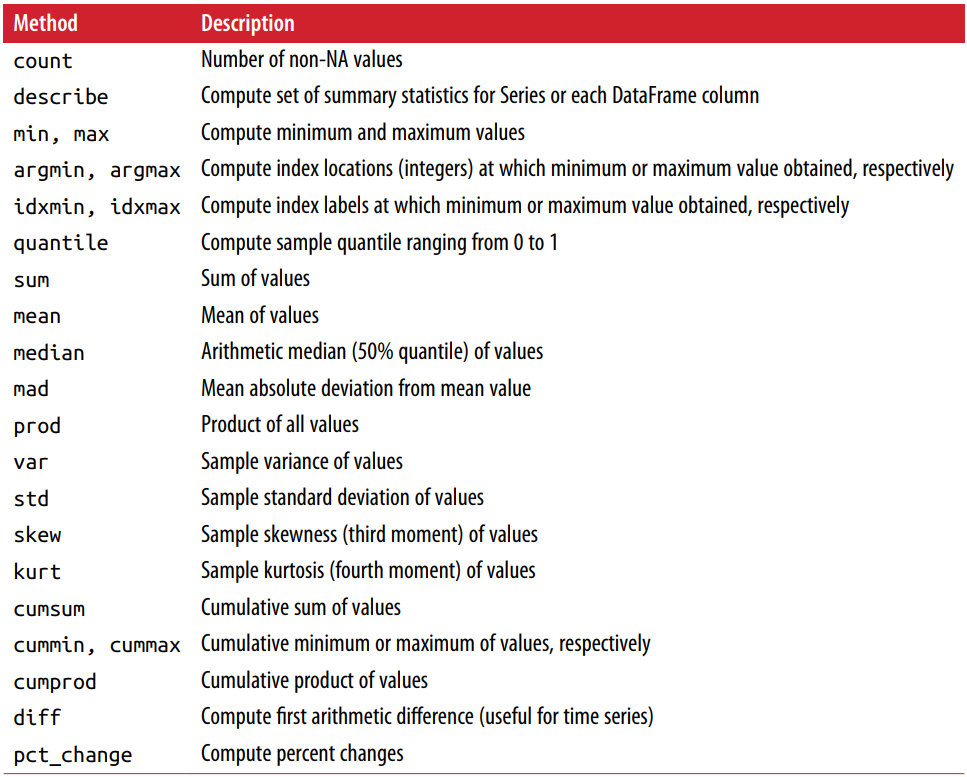

### **Unique Values, Value Counts, and Membership**

Following methods extract information about the values contained in a one-dimensional Series.

In [ ]:
obj = pd.Series(['c', 'a', 'd', 'a', 'a', 'b', 'b', 'c', 'c'])

uniques = obj.unique()

In [ ]:
uniques

array(['c', 'a', 'd', 'b'], dtype=object)

The unique values are not necessarily returned in sorted order, but could be sorted after the fact if needed (uniques.sort()).

In [ ]:
uniques.sort()
uniques

array(['a', 'b', 'c', 'd'], dtype=object)

value_counts computes a Series
containing value frequencies:

In [ ]:
obj.value_counts()

,count
c,3
a,3
b,2
d,1


The Series is sorted by value in descending order as a convenience.

In [ ]:
obj.value_counts(sort = False)

,count
c,3
a,3
d,1
b,2


isin performs a vectorized set membership check and can be useful in filtering a dataset down to a subset of values in a Series or column in a DataFrame:

In [ ]:
obj

,0
0,c
1,a
2,d
3,a
4,a
5,b
6,b
7,c
8,c


In [ ]:
mask = obj.isin(['b', 'c'])
# mask = obj.isin(['b'])
mask

,0
0,True
1,False
2,False
3,False
4,False
5,True
6,True
7,True
8,True


In [ ]:
obj[mask]

,0
0,c
5,b
6,b
7,c
8,c


# **Reading and Writing Data in Text Format**

pandas features a number of functions for reading tabular data as a DataFrame object. However `read_csv` and `read_table` are the most used ones.

Because of how messy data in the real world can be, some of the data loading functions (especially read_csv) have grown very complex in their options over time.

It's normal to feel overwhelmed by the number of different parameters (read_csv has over 50 as of this writing).

The online pandas documentation has many examples about how each of them works, so if you're struggling to read a particular file, there might be a similar enough example to help you find the right parameters.

Some of these functions, like pandas.read_csv, perform type inference, because the column data types are not part of the data format.

That means you don't necessarily have to specify which columns are numeric, integer, boolean, or string.

Other data formats, like HDF5, Feather, and msgpack, have the data types stored in the format.

We need to create a csv file and upload that to the current session.

Add following data to the file and save as ex1.csv
```
a,b,c,d,message
1,2,3,4,hello
5,6,7,8,world
9,10,11,12,foo
```

In [97]:
df = pd.read_csv('examples/ex1.csv')

df


,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


We could also have used read_table and specified the delimiter:

In [98]:
pd.read_table('examples/ex1.csv', sep=',')

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


A file will not always have a header row.

Create a file with data "ex2.csv":
```
1,2,3,4,hello
5,6,7,8,world
9,10,11,12,foo
```

You can allow pandas to assign default column names, or you can specify names yourself:

In [99]:
pd.read_csv('examples/ex2.csv', header=None)

,0,1,2,3,4
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [100]:
pd.read_csv('examples/ex2.csv', names=['a', 'b', 'c', 'd', 'message'])

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In case you want to form a hierarchical index from multiple columns, pass a list of column numbers or names:

Create a file with following data
```
examples/csv_mindex.csv
key1,key2,value1,value2
one,a,1,2
one,b,3,4
one,c,5,6
one,d,7,8
two,a,9,10
two,b,11,12
two,c,13,14
two,d,15,16
```

In [101]:
parsed = pd.read_csv('examples/csv_mindex.csv',
                     index_col=['key1', 'key2'])

parsed

value1  value2
key1 key2                
one  a          1       2
     b          3       4
     c          5       6
     d          7       8
two  a          9      10
     b         11      12
     c         13      14
     d         15      16

In some cases, a table might not have a fixed delimiter, using whitespace or some other pattern to separate fields.

In [102]:
list(open('examples/ex3.txt'))

[' A B C\n',
 'aaa -0.264438 -1.026059 -0.619500\n',
 'bbb 0.927272 0.302904 -0.032399\n',
 'ccc -0.264273 -0.386314 -0.217601\n',
 'ddd -0.871858 -0.348382 1.100491\n']

While you could do some munging by hand, the fields here are separated by a variable amount of whitespace.

In these cases, you can pass a regular expression as a delimiter for read_table.

This can be expressed by the regular expression `\s+`, so we have then:

In [103]:
result = pd.read_table('examples/ex3.txt', sep='\s+')

result

,A,B,C
aaa,-0.264438,-1.026059,-0.619500
bbb,0.927272,0.302904,-0.032399
ccc,-0.264273,-0.386314,-0.217601
ddd,-0.871858,-0.348382,1.100491


Because there was one fewer column name than the number of data rows, `read_table` infers that the first column should be the DataFrame's index in this special case.

The parser functions have many additional arguments to help you handle a wide variety of exception file formats that occur. For example, you can skip the first, third, and fourth rows of a file with skiprows:

In [104]:
pd.read_csv('examples/ex4.txt', skiprows=[0, 2, 3])

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


Handling missing values is an important and frequently nuanced part of the file parsing process.

Missing data is usually either not present (empty string) or marked by some sentinel value.

By default, pandas uses a set of commonly occurring sentinels, such as `NA` and `NULL`:

In [ ]:
result = pd.read_csv('examples/ex5.csv')

result

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


In [ ]:
pd.isnull(result)

,something,a,b,c,d,message
0,False,False,False,False,False,True
1,False,False,False,True,False,False
2,False,False,False,False,False,False


The na_values option can take either a list or set of strings to consider missing values:

In [ ]:
result = pd.read_csv('examples/ex5.csv', na_values=['NULL'])

result

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


Different NA sentinels can be specified for each column in a dict:

In [ ]:
sentinels = {'message': ['foo', 'NA'], 'something': ['two']}

pd.read_csv('examples/ex5.csv', na_values=sentinels)

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,NaN,5,6,NaN,8,world
2,three,9,10,11.0,12,NaN


Following table lists some frequently used options in `pandas.read_csv` and `pandas.read_table`

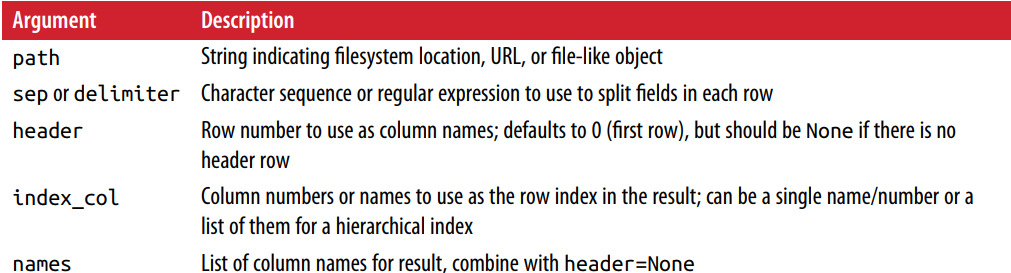
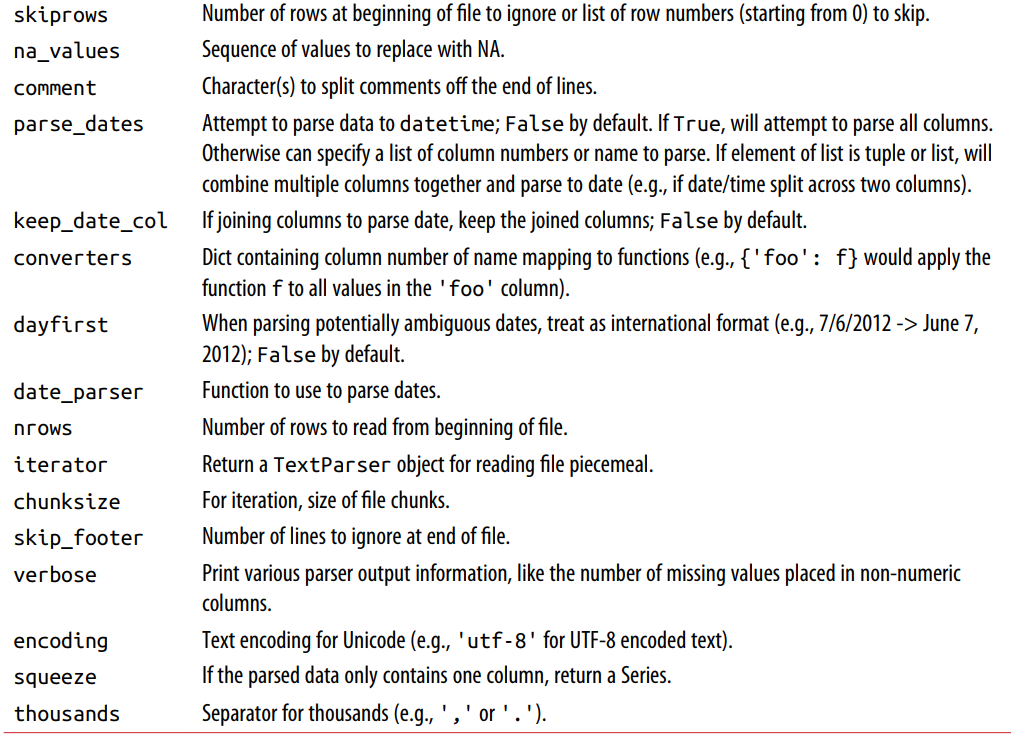

## **Reading Text Files in Pieces**

When processing very large files or figuring out the right set of arguments to correctly process a large file, you may only want to read in a small piece of a file or iterate through smaller chunks of the file.

Before we look at a large file, we make the pandas display settings more compact:

In [ ]:
pd.options.display.max_rows = 10

In [ ]:
result = pd.read_csv('examples/ex6.csv')

result

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
4,0.354628,-0.133116,0.283763,-0.837063,Q
...,...,...,...,...,...
9995,2.311896,-0.417070,-1.409599,-0.515821,L
9996,-0.479893,-0.650419,0.745152,-0.646038,E
9997,0.523331,0.787112,0.486066,1.093156,K
9998,-0.362559,0.598894,-1.843201,0.887292,G


If you want to only read a small number of rows (avoiding reading the entire file), specify that with nrows:

In [ ]:
pd.read_csv('examples/ex6.csv', nrows=5)

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
4,0.354628,-0.133116,0.283763,-0.837063,Q


## **Writing Data to Text Format**

Data can also be exported to a delimited format. Let’s consider one of the CSV files read before:

In [105]:
data = pd.read_csv('examples/ex5.csv')
data

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


Using DataFrame’s `to_csv` method, we can write the data out to a comma-separated file:

In [106]:
data.to_csv('examples/out.csv')
!cat examples/out.csv

,something,a,b,c,d,message
0,one,1,2,3.0,4,
1,two,5,6,,8,world
2,three,9,10,11.0,12,foo


Other delimiters can be used, of course (writing to `sys.stdout` so it prints the text result to the console):

In [ ]:
import sys
data.to_csv(sys.stdout, sep='|')

|something|a|b|c|d|message
0|one|1|2|3.0|4|
1|two|5|6||8|world
2|three|9|10|11.0|12|foo


Missing values appear as empty strings in the output. You might want to denote them by some other sentinel value:

In [ ]:
data.to_csv(sys.stdout, na_rep='NULL')

,something,a,b,c,d,message
0,one,1,2,3.0,4,NULL
1,two,5,6,NULL,8,world
2,three,9,10,11.0,12,foo


With no other options specified, both the row and column labels are written. Both of these can be disabled:

In [ ]:
data.to_csv(sys.stdout, index=False, header=False)

one,1,2,3.0,4,
two,5,6,,8,world
three,9,10,11.0,12,foo


You can also write only a subset of the columns, and in an order of your choosing:

In [ ]:
data.to_csv(sys.stdout, index=False, columns=['a', 'b', 'c'])

a,b,c
1,2,3.0
5,6,
9,10,11.0


Series also has a to_csv method:

In [ ]:
dates = pd.date_range('1/1/2000', periods=7)
ts = pd.Series(np.arange(7), index=dates)
ts.to_csv('examples/tseries.csv')
!cat examples/tseries.csv

,0
2000-01-01,0
2000-01-02,1
2000-01-03,2
2000-01-04,3
2000-01-05,4
2000-01-06,5
2000-01-07,6


## **Working with Delimited Formats**

It's possible to load most forms of tabular data from disk using functions like `pandas.read_table`.

In some cases, however, some manual processing may be necessary. We may receive a file with one or more malformed lines that trip up `read_table`.

To illustrate the basic tools, consider a small CSV file:

In [ ]:
!cat examples/ex7.csv

"a","b","c"
"1","2","3"
"1","2","3"


For any file with a single-character delimiter, you can use Python’s built-in csv module.

To use it, pass any open file or file-like object to csv.reader:

In [ ]:
import csv
f = open('examples/ex7.csv')

reader = csv.reader(f)

Iterating through the reader like a file yields list of values with any quote characters removed:

In [ ]:
for line in reader:
    print(line)

['a', 'b', 'c']
['1', '2', '3']
['1', '2', '3']


From there, it’s up to you to do the wrangling necessary to put the data in the form that you need it.

Let’s take this step by step. First, we read the file into a list of lines:

In [ ]:
with open('examples/ex7.csv') as f:
    lines = list(csv.reader(f))

Then, we split the lines into the header line and the data lines:

In [ ]:
header, values = lines[0], lines[1:]

Then we can create a dictionary of data columns using a dictionary comprehension and the expression `zip(*values)`, which transposes rows to columns.

Note: The `zip()` function in Python combines multiple iterables such as lists, tuples, strings, dict etc, into a single iterator of tuples. Each tuple contains elements from the input iterables that are at the same position.

In [ ]:
data_dict = {h: v for h, v in zip(header, zip(*values))}
data_dict

{'a': ('1', '1'), 'b': ('2', '2'), 'c': ('3', '3')}

## **JSON Data**

JSON (short for JavaScript Object Notation) has become one of the standard formats for sending data by HTTP request between web browsers and other applications.

It is a much more free-form data format than a tabular text form like CSV.

Here is an example:

In [ ]:
obj = """
{"name": "Wes",
 "places_lived": ["United States", "Spain", "Germany"],
 "pet": null,
 "siblings": [{"name": "Scott", "age": 30, "pets": ["Zeus", "Zuko"]},
              {"name": "Katie", "age": 38,
               "pets": ["Sixes", "Stache", "Cisco"]}]
}
"""

JSON is very nearly valid Python code with the exception of its null value null and some other nuances (such as disallowing trailing commas at the end of lists).

The basic types are objects (dicts), arrays (lists), strings, numbers, booleans, and nulls.

All of the keys in an object must be strings.

There are several Python libraries for reading and writing JSON data.

We'll use `json` here, as it is built into the Python standard library.

To convert a JSON string to Python form, use `json.loads`:

In [ ]:
import json
result = json.loads(obj)
result

{'name': 'Wes',
 'places_lived': ['United States', 'Spain', 'Germany'],
 'pet': None,
 'siblings': [{'name': 'Scott', 'age': 30, 'pets': ['Zeus', 'Zuko']},
  {'name': 'Katie', 'age': 38, 'pets': ['Sixes', 'Stache', 'Cisco']}]}

json.dumps, on the other hand, converts a Python object back to JSON:

In [ ]:
asjson = json.dumps(result)

How you convert a JSON object or list of objects to a DataFrame or some other data structure for analysis will be up to you.

Conveniently, you can pass a list of dicts (which were previously JSON objects) to the DataFrame constructor and select a subset of the data fields:

In [ ]:
siblings = pd.DataFrame(result['siblings'], columns=['name', 'age'])
siblings

,name,age
0,Scott,30
1,Katie,38


The pandas.read_json can automatically convert JSON datasets in specific arrangements into a Series or DataFrame.

For example:

In [ ]:
!cat examples/example.json

[{"a": 1, "b": 2, "c": 3},
 {"a": 4, "b": 5, "c": 6},
 {"a": 7, "b": 8, "c": 9}]


The default options for `pandas.read_json` assume that each object in the JSON array is a row in the table:

In [ ]:
data = pd.read_json('examples/example.json')
data

,a,b,c
0,1,2,3
1,4,5,6
2,7,8,9


If you need to export data from pandas to JSON, one way is to use the `to_json` methods on Series and DataFrame:

In [ ]:
print(data.to_json())
print(data.to_json(orient='records'))

{"a":{"0":1,"1":4,"2":7},"b":{"0":2,"1":5,"2":8},"c":{"0":3,"1":6,"2":9}}
[{"a":1,"b":2,"c":3},{"a":4,"b":5,"c":6},{"a":7,"b":8,"c":9}]


**References**:

1. [Python for Data Analysis: Data Wrangling with Pandas, NumPy,and IPython by Wes McKinney, Second Ed., O'Reilly Media](https://www.oreilly.com/library/view/python-for-data/9781491957653/)